# 05 — Business Impact Quantification (PRD Phase 8)

What the fraud ensemble is worth in money, and what it costs in customer
friction to earn it.

**Scope.** Everything below describes the *deployed* configuration: the weights
and operating threshold in `models/ensemble.json` (XGB 0.608 / LGBM 0.384 /
TFT 0.008, threshold 0.012251 — the PRD Phase 9 step 9.4 promoted 3-way
ensemble, `dataset_hash d20f03c0…`), scored on the held-out test split. The
probabilities are exported once by `scripts/export_test_probabilities.py`; this
notebook does not re-fit or re-optimise anything, so the numbers here are the
numbers production would produce.

**A caveat stated up front, not buried.** The cost model in `config/config.yaml`
credits `revenue_tp = $480` for catching a fraud *and* charges `cost_fn = $500`
for missing one. Those double-count the same recovered principal: the swing
between catching and missing one $500 fraud comes to $980. Section 6 quantifies
what that distortion does to the recommended threshold. It is a business
modelling question (ADR-001 §6.3), not an arithmetic bug, so this notebook
reports the PRD formula as specified *and* the single-counted alternative side
by side rather than silently picking one.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import yaml

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.business_impact import (
    CONVENTION_NET,
    CONVENTION_PRD,
    CostModel,
    TransactionVolume,
    best_threshold,
    compute_impact,
    confusion_at_threshold,
    threshold_sweep,
)

with open(PROJECT_ROOT / 'config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'


def money(x):
    """Format a dollar amount for a business reader."""
    return f'${x:,.0f}'

## 1. Cost matrix and the annual book of business

The per-outcome amounts come from `config/config.yaml:thresholds` — the same
block `ModelEvaluator` selects the operating threshold against, so the report
and the deployed decision rule cannot drift onto different numbers.

Volume is the dataset's own scale annualised (PRD §8.1): 590,540 transactions
over ~180 days. The fraud rate is measured on the test split rather than
assumed, so the projection describes the data actually being scored.

In [2]:
probs = np.load(PROJECT_ROOT / 'reports' / 'ensemble_test_probabilities.npz')
y_true = probs['y_true']
y_prob = probs['y_prob']
DEPLOYED_THRESHOLD = float(probs['threshold'])

costs = CostModel.from_config(config)
volume = TransactionVolume.from_dataset(fraud_rate=float(y_true.mean()))

print(f'Test split:            {len(y_true):,} transactions, {int(y_true.sum()):,} fraud')
print(f'Measured fraud rate:   {y_true.mean():.4f}')
print()
print(f'cost_fn    (missed fraud):     {money(costs.cost_fn)}')
print(f'cost_fp    (blocked customer): {money(costs.cost_fp)}')
print(f'revenue_tp (fraud caught):     {money(costs.revenue_tp)}')
print(f'--> implied swing per fraud:   {money(costs.implied_fraud_swing)}  '
      f'(vs {money(costs.cost_fn)} actually at stake -- see Section 6)')
print()
print(f'Annual transactions:   {volume.annual_transactions:,.0f}')
print(f'Annual fraud:          {volume.annual_fraud:,.0f}')
print(f'Annual legitimate:     {volume.annual_legitimate:,.0f}')
print(f'Deployed threshold:    {DEPLOYED_THRESHOLD:.6f}')

Test split:            118,109 transactions, 4,064 fraud
Measured fraud rate:   0.0344

cost_fn    (missed fraud):     $500
cost_fp    (blocked customer): $5
revenue_tp (fraud caught):     $480
--> implied swing per fraud:   $980  (vs $500 actually at stake -- see Section 6)

Annual transactions:   1,197,484
Annual fraud:          41,204
Annual legitimate:     1,156,280
Deployed threshold:    0.012251


## 2. Model performance translated into annual outcomes

Recall and false-positive rate are measured on the test split, then applied to
the annual volume. Raw counts are never scaled directly, so these figures do not
move with the size of the evaluation split.

In [3]:
counts = confusion_at_threshold(y_true, y_prob, DEPLOYED_THRESHOLD)
impact_prd = compute_impact(
    y_true, y_prob, DEPLOYED_THRESHOLD, costs, volume, CONVENTION_PRD
)

print('Test-split confusion matrix at the deployed threshold')
print(f"  TP {counts['tp']:>7,}   FN {counts['fn']:>7,}")
print(f"  FP {counts['fp']:>7,}   TN {counts['tn']:>7,}")
print()
print(f'  Recall     {impact_prd.recall:.4f}')
print(f'  Precision  {impact_prd.precision:.4f}')
print(f'  FPR        {impact_prd.false_positive_rate:.4f}')
print()
print('Projected to one year')
print(f'  Fraud caught (TP)      {impact_prd.annual_tp:>12,.0f}')
print(f'  Fraud missed (FN)      {impact_prd.annual_fn:>12,.0f}')
print(f'  Customers blocked (FP) {impact_prd.annual_fp:>12,.0f}')

Test-split confusion matrix at the deployed threshold
  TP   3,677   FN     387
  FP  33,139   TN  80,906

  Recall     0.9048
  Precision  0.0999
  FPR        0.2906

Projected to one year
  Fraud caught (TP)            37,280
  Fraud missed (FN)             3,924
  Customers blocked (FP)      335,990


In [4]:
pnl = pd.DataFrame([
    {'Line item': 'Gross benefit (fraud prevented)', 'Amount': impact_prd.gross_benefit},
    {'Line item': 'Cost of missed fraud', 'Amount': -impact_prd.false_negative_loss},
    {'Line item': 'Cost of false alarms', 'Amount': -impact_prd.false_positive_cost},
    {'Line item': 'Net annual value', 'Amount': impact_prd.net_annual_value},
])
pnl['Amount'] = pnl['Amount'].map(money)
pnl

,Line item,Amount
0,Gross benefit (fraud prevented),"$17,894,582"
1,Cost of missed fraud,"$-1,961,858"
2,Cost of false alarms,"$-1,679,949"
3,Net annual value,"$14,252,774"


## 3. Threshold sensitivity

The grid is **log-spaced from 1e-4**, mirroring
`ModelEvaluator._select_threshold_grid`. The PRD sketches a linear 0.01–0.99
sweep, but the deployed operating point is 0.006 — below that floor — so a
linear grid would not contain the optimum and the plot would miss the peak
entirely.

In [5]:
sweep_prd = threshold_sweep(y_true, y_prob, costs, volume=volume, convention=CONVENTION_PRD)
sweep_net = threshold_sweep(y_true, y_prob, costs, volume=volume, convention=CONVENTION_NET)

best_prd = best_threshold(sweep_prd)
best_net = best_threshold(sweep_net)

print(f'PRD convention   optimum t={best_prd.threshold:.6f}  '
      f'net {money(best_prd.net_annual_value)}  recall {best_prd.recall:.3f}')
print(f'Net of principal optimum t={best_net.threshold:.6f}  '
      f'net {money(best_net.net_annual_value)}  recall {best_net.recall:.3f}')
print(f'Deployed         t={DEPLOYED_THRESHOLD:.6f}  '
      f'net {money(impact_prd.net_annual_value)}  recall {impact_prd.recall:.3f}')

PRD convention   optimum t=0.004640  net $15,328,248  recall 0.965
Net of principal optimum t=0.008864  net $16,323,625  recall 0.932
Deployed         t=0.012251  net $14,252,774  recall 0.905


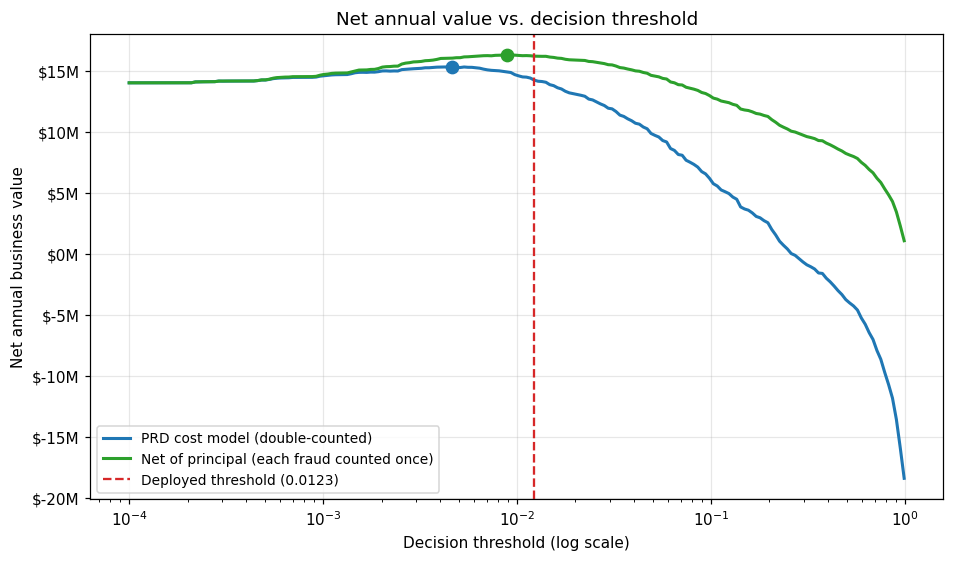

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot([i.threshold for i in sweep_prd], [i.net_annual_value for i in sweep_prd],
        lw=2, color='#1f77b4', label='PRD cost model (double-counted)')
ax.plot([i.threshold for i in sweep_net], [i.net_annual_value for i in sweep_net],
        lw=2, color='#2ca02c', label='Net of principal (each fraud counted once)')

ax.axvline(DEPLOYED_THRESHOLD, color='#d62728', ls='--', lw=1.5,
           label=f'Deployed threshold ({DEPLOYED_THRESHOLD:.4f})')
ax.plot([best_prd.threshold], [best_prd.net_annual_value], 'o', color='#1f77b4', ms=8)
ax.plot([best_net.threshold], [best_net.net_annual_value], 'o', color='#2ca02c', ms=8)

ax.set_xscale('log')
ax.set_xlabel('Decision threshold (log scale)')
ax.set_ylabel('Net annual business value')
ax.set_title('Net annual value vs. decision threshold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v/1e6:.0f}M'))
ax.grid(alpha=0.3)
ax.legend(loc='lower left', fontsize=9)

fig.savefig(FIGURES_DIR / 'business_value_vs_threshold.png')
plt.show()

### 3.1 The curve is flat where it matters

The peak is worth less than the plot suggests. Because the value curve is broad,
thresholds far above the optimum give up only a small fraction of the money
while cutting false positives several-fold — and false positives are the cost
this model understates, since `cost_fp = $5` prices a blocked customer as a
support call and nothing else (no churn, no lifetime value).

In [7]:
rows = []
for t in [DEPLOYED_THRESHOLD, 0.01, 0.05, 0.10, 0.30, 0.50]:
    i = compute_impact(y_true, y_prob, t, costs, volume, CONVENTION_NET)
    rows.append({
        'Threshold': f'{t:.4f}',
        'Recall': f'{i.recall:.3f}',
        'Precision': f'{i.precision:.3f}',
        'Customers blocked/yr': f'{i.annual_fp:,.0f}',
        'FP per fraud caught': f'{i.false_positives_per_fraud_caught:.1f}',
        'Net annual value': money(i.net_annual_value),
        '% of peak': f'{100 * i.net_annual_value / best_net.net_annual_value:.1f}%',
    })
pd.DataFrame(rows)

,Threshold,Recall,Precision,Customers blocked/yr,FP per fraud caught,Net annual value,% of peak
0,0.0123,0.905,0.100,"335,990",9.0,"$16,214,633",99.3%
1,0.0100,0.920,0.090,"381,848",10.1,"$16,277,341",99.7%
2,0.0500,0.766,0.223,"109,965",3.5,"$14,604,844",89.5%
3,0.1000,0.661,0.332,"54,932",2.0,"$12,806,829",78.5%
4,0.3000,0.496,0.577,"14,975",0.7,"$9,731,375",59.6%
5,0.5000,0.419,0.686,"7,898",0.5,"$8,243,506",50.5%


## 4. Comparison against the naive baseline

The "flag nothing" model catches no fraud, blocks no customers, and needs no
infrastructure. Under the PRD convention it loses the entire annual fraud book;
under the single-counted convention its value is zero by construction (it *is*
the reference point). Either way the gap is what the model earns.

In [8]:
impact_net = compute_impact(
    y_true, y_prob, DEPLOYED_THRESHOLD, costs, volume, CONVENTION_NET
)

pd.DataFrame([
    {
        'Convention': name,
        'Model net annual value': money(impact.net_annual_value),
        '"Flag nothing" baseline': money(impact.naive_baseline_value),
        'Improvement over baseline': money(impact.improvement_over_naive),
    }
    for name, impact in [('PRD formula', impact_prd), ('Net of principal', impact_net)]
])

,Convention,Model net annual value,"""Flag nothing"" baseline",Improvement over baseline
0,PRD formula,"$14,252,774","$-20,602,048","$34,854,822"
1,Net of principal,"$16,214,633",$0,"$16,214,633"


## 5. Executive summary

In [9]:
i = impact_prd
n = impact_net

summary = f'''
## Model Business Summary

At the deployed operating threshold of {DEPLOYED_THRESHOLD:.6f}:

| Metric | Value |
|--------|-------|
| Annual transactions modeled | {i.annual_transactions:,.0f} |
| Fraud cases detected | {i.annual_tp:,.0f} ({i.recall:.1%} recall) |
| Fraud cases missed | {i.annual_fn:,.0f} |
| Legitimate transactions blocked | {i.annual_fp:,.0f} ({i.false_positive_rate:.2%} FPR) |
| Legitimate blocked per fraud caught | {i.false_positives_per_fraud_caught:.1f} |
| Gross value from fraud prevention | {money(i.gross_benefit)} |
| Cost of missed fraud (PRD convention) | {money(i.false_negative_loss)} |
| Cost of false alarms | {money(i.false_positive_cost)} |
| **Net annual business value (PRD convention)** | **{money(i.net_annual_value)}** |
| **Net annual business value (net of principal)** | **{money(n.net_annual_value)}** |
| Improvement over "flag nothing" baseline (PRD) | {money(i.improvement_over_naive)} |

Model interpretability is provided via SHAP values on every prediction
(`src/serving/explainability.py`), supporting RBI Model Risk Management and FCA
Model Risk review requirements.

**Read the two net-value rows together, not separately.** They differ by
{money(n.net_annual_value - i.net_annual_value)} because the PRD cost model
charges the missed-fraud principal twice; Section 6 shows the threshold
consequence.
'''.strip()

from IPython.display import Markdown
Markdown(summary)

## Model Business Summary

At the deployed operating threshold of 0.012251:

| Metric | Value |
|--------|-------|
| Annual transactions modeled | 1,197,484 |
| Fraud cases detected | 37,280 (90.5% recall) |
| Fraud cases missed | 3,924 |
| Legitimate transactions blocked | 335,990 (29.06% FPR) |
| Legitimate blocked per fraud caught | 9.0 |
| Gross value from fraud prevention | $17,894,582 |
| Cost of missed fraud (PRD convention) | $1,961,858 |
| Cost of false alarms | $1,679,949 |
| **Net annual business value (PRD convention)** | **$14,252,774** |
| **Net annual business value (net of principal)** | **$16,214,633** |
| Improvement over "flag nothing" baseline (PRD) | $34,854,822 |

Model interpretability is provided via SHAP values on every prediction
(`src/serving/explainability.py`), supporting RBI Model Risk Management and FCA
Model Risk review requirements.

**Read the two net-value rows together, not separately.** They differ by
$1,961,858 because the PRD cost model
charges the missed-fraud principal twice; Section 6 shows the threshold
consequence.

## 6. The cost-model double-count, quantified

`revenue_tp = 480` and `cost_fn = 500` describe the same $500 of recovered
principal from two directions. Booking both makes one fraud worth $980 of swing
— roughly twice its true value — while a blocked customer stays priced at $5.
Inflating one side of a trade-off moves the optimum, so this is not a cosmetic
issue.

In [10]:
delta_recall = best_prd.recall - best_net.recall
delta_fp = best_prd.annual_fp - best_net.annual_fp

print('Optimal threshold under each convention')
print(f'  PRD (double-counted): t={best_prd.threshold:.6f}  '
      f'recall {best_prd.recall:.3f}  blocked/yr {best_prd.annual_fp:,.0f}  '
      f'FP per catch {best_prd.false_positives_per_fraud_caught:.1f}')
print(f'  Net of principal:     t={best_net.threshold:.6f}  '
      f'recall {best_net.recall:.3f}  blocked/yr {best_net.annual_fp:,.0f}  '
      f'FP per catch {best_net.false_positives_per_fraud_caught:.1f}')
print()
print(f'The double-count lowers the recommended threshold '
      f'{best_net.threshold / best_prd.threshold:.1f}x, buying '
      f'{delta_recall:+.1%} recall at the price of {delta_fp:,.0f} additional '
      f'blocked customers per year.')

Optimal threshold under each convention
  PRD (double-counted): t=0.004640  recall 0.965  blocked/yr 605,773  FP per catch 15.2
  Net of principal:     t=0.008864  recall 0.932  blocked/yr 421,257  FP per catch 11.0

The double-count lowers the recommended threshold 1.9x, buying +3.3% recall at the price of 184,516 additional blocked customers per year.


**What to do with this.** The threshold is frozen in `models/ensemble.json` and
is not changed here — retuning an operating point is a deployment decision, not
a notebook's. The recommendation for the business is:

1. **Settle the definition of `revenue_tp`.** If it means recovery *net* of the
   principal, the current config is right and no change is needed. If it means
   the recovered principal itself, `cost_fn` is double-charging and the
   single-counted column is the honest one.
2. **Price a false positive properly.** At $5 a blocked customer is a support
   call. Any allowance for churn or lifetime value would raise `cost_fp`
   sharply and push the optimum well above either figure here — likely toward
   the flat region in §3.1, where most of the value survives at a fraction of
   the friction.
3. **Note that the ranking question is robust.** Both conventions agree the
   model is worth eight figures a year versus doing nothing. The disagreement is
   about *where to operate*, not *whether to deploy*.

## 7. Artifacts written

| Artifact | Path |
|---|---|
| Threshold sensitivity plot | `reports/figures/business_value_vs_threshold.png` |
| Blended test probabilities | `reports/ensemble_test_probabilities.npz` |
| Impact arithmetic (unit-tested) | `src/evaluation/business_impact.py` |